# AutoLSM-Swarm — sanity checks & visualizations

Quick checks for the pipeline:

1. Load and preview the labeled landslide tile dataset.
2. Browse `runs/` (rounds, agents, ledger) and pick one agent's pipeline.
3. Re-run that pipeline's `preprocess -> build_model -> train` (models aren't persisted to disk, only `pipeline.py` is, so this reproduces `driver.py`'s training step) and run inference on sample tiles.
4. Evaluate the resulting predictions (Dice/IoU) and display prediction/error maps for that group of inferences.

In [2]:
import sys
import json
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "src").exists(), f"couldn't find src/ from {REPO_ROOT} -- run this notebook from the repo root"
sys.path.insert(0, str(REPO_ROOT / "src"))

from config import Settings
from data.dataset import load_split
from eval.infer import infer, evaluate
from eval.metrics import dice, iou
from agents.pipeline_contract import validate_module, ContractError

settings = Settings()
print(f"dataset_dir: {settings.dataset_dir}")
print(f"runs_dir:    {settings.runs_dir}")

dataset_dir: D:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\archive
runs_dir:    D:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\runs


## 1. Dataset

Each tile is `(128, 128, 14)`: bands B1-B12 (Sentinel-2-style, channels 0-11), slope (channel 12) and DEM (channel 13), with a binary `(128, 128)` landslide mask.

In [3]:
BAND_NAMES = [f"B{i+1}" for i in range(12)] + ["slope", "dem"]


def stretch(channel: np.ndarray) -> np.ndarray:
    """2-98 percentile contrast stretch for display only."""
    lo, hi = np.percentile(channel, [2, 98])
    if hi - lo < 1e-6:
        lo, hi = float(channel.min()), float(channel.max()) + 1e-6
    return np.clip((channel - lo) / (hi - lo), 0.0, 1.0)


def rgb_composite(tile: np.ndarray) -> np.ndarray:
    """True-color composite from bands B4(red)/B3(green)/B2(blue) -> channels 3,2,1."""
    return np.stack([stretch(tile[:, :, i]) for i in (3, 2, 1)], axis=-1)


def ndvi(tile: np.ndarray) -> np.ndarray:
    b8, b4 = tile[:, :, 7].astype(np.float64), tile[:, :, 3].astype(np.float64)
    return (b8 - b4) / (b8 + b4 + 1e-6)


def plot_dataset_samples(X: np.ndarray, y: np.ndarray, ids: list[int], n: int = 4, seed: int = 0) -> None:
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=min(n, len(X)), replace=False)
    fig, axes = plt.subplots(len(idxs), 5, figsize=(15, 3 * len(idxs)))
    axes = np.atleast_2d(axes)
    col_titles = ["RGB (B4/B3/B2)", "NDVI", "slope", "DEM", "mask (landslide)"]
    for row, idx in enumerate(idxs):
        tile, mask = X[idx], y[idx]
        panels = [rgb_composite(tile), stretch(ndvi(tile)), stretch(tile[:, :, 12]), stretch(tile[:, :, 13]), mask]
        cmaps = [None, "RdYlGn", "terrain", "terrain", "Reds"]
        for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
            ax = axes[row, col]
            ax.imshow(panel, cmap=cmap, vmin=0 if cmap == "Reds" else None, vmax=1 if cmap == "Reds" else None)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(col_titles[col], fontsize=10)
            if col == 0:
                ax.set_ylabel(f"tile {ids[idx]}", fontsize=9)
    fig.suptitle("Dataset preview", y=1.0)
    fig.tight_layout()
    plt.show()

train: X=(200, 128, 128, 14) y=(200, 128, 128)
val:   X=(100, 128, 128, 14) y=(100, 128, 128)
train: landslide pixels=2.293%, tiles containing landslide=71.5%
val: landslide pixels=3.329%, tiles containing landslide=80.0%


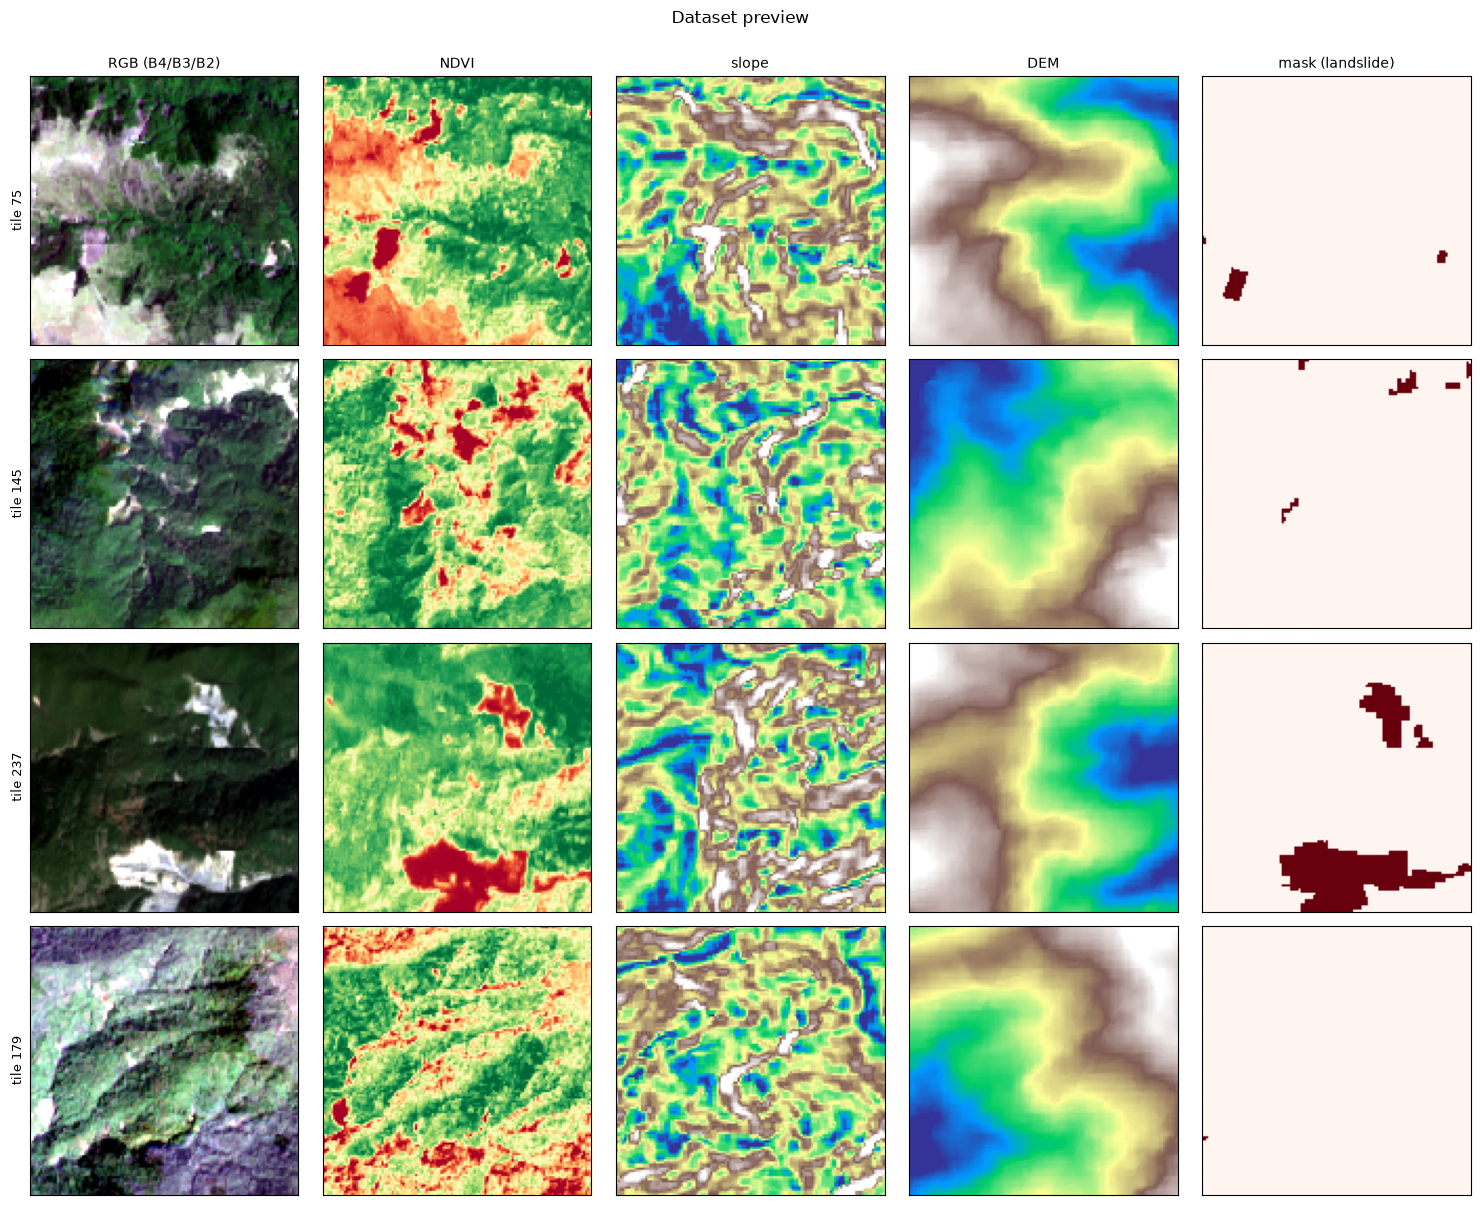

In [4]:
# Load the same fixed, seeded splits the pipeline trains/evaluates on.
# Caps default to the project settings; lower them here for a faster notebook pass.
MAX_TRAIN_TILES = settings.max_train_tiles
MAX_VAL_TILES = settings.max_val_tiles

X_train, y_train, train_ids = load_split("train", settings.dataset_dir, MAX_TRAIN_TILES)
X_val, y_val, val_ids = load_split("val", settings.dataset_dir, MAX_VAL_TILES)

print(f"train: X={X_train.shape} y={y_train.shape}")
print(f"val:   X={X_val.shape} y={y_val.shape}")
for name, y in [("train", y_train), ("val", y_val)]:
    pos_frac = y.mean()
    tiles_with_landslide = (y.reshape(len(y), -1).sum(axis=1) > 0).mean()
    print(f"{name}: landslide pixels={pos_frac:.3%}, tiles containing landslide={tiles_with_landslide:.1%}")

plot_dataset_samples(X_train, y_train, train_ids, n=4)

## 2. Runs / rounds / agents

Storage layout: `runs/<run_id>/round_<t>/agent_<i>/{skill.md, pipeline.py, driver_stdout.json}`, plus a per-run `ledger.jsonl` (one line per agent per round) and `summary.json`.

In [5]:
def list_runs() -> list[str]:
    if not settings.runs_dir.exists():
        return []
    return sorted(p.name for p in settings.runs_dir.iterdir() if p.is_dir() and (p / "ledger.jsonl").exists())


def list_rounds(run_id: str) -> list[int]:
    run_dir = settings.runs_dir / run_id
    return sorted(int(p.name.split("_")[1]) for p in run_dir.glob("round_*") if p.is_dir())


def list_agents(run_id: str, round_idx: int) -> list[int]:
    round_dir = settings.runs_dir / run_id / f"round_{round_idx}"
    return sorted(int(p.name.split("_")[1]) for p in round_dir.glob("agent_*") if p.is_dir())


def load_ledger(run_id: str) -> pd.DataFrame:
    path = settings.runs_dir / run_id / "ledger.jsonl"
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return pd.DataFrame(rows)


runs = list_runs()
print(f"found {len(runs)} run(s):")
for r in runs:
    print(" ", r)

found 2 run(s):
  20260911_005237
  20260911_173527


In [6]:
# --- pick a run / round / agent to inspect -------------------------------------
RUN_ID = runs[-1] if runs else None  # defaults to the most recent run; override freely
assert RUN_ID is not None, "no runs found under settings.runs_dir -- run `python main.py` first"

ledger = load_ledger(RUN_ID)
rounds = list_rounds(RUN_ID)
# ROUND = rounds[-1]  # defaults to the latest round reached by this run

ROUND = int(ledger.loc[ledger["dice"].idxmax(), "round"]) if len(ledger) else 0
round_rows = ledger[ledger["round"] == ROUND]
AGENT_IDX = int(round_rows.loc[round_rows["dice"].idxmax(), "agent_idx"]) if len(round_rows) else 0

print(f"RUN_ID={RUN_ID}  ROUND={ROUND} (of {rounds})  AGENT_IDX={AGENT_IDX} (best Dice this round)")
ledger.sort_values(["round", "agent_idx"]).reset_index(drop=True)

RUN_ID=20260911_173527  ROUND=1 (of [0, 1, 2, 3, 4])  AGENT_IDX=2 (best Dice this round)


,round,agent_idx,dice,iou,success,error,carried_forward,retrieved_papers,cited_papers,debug_iters
0,0,0,6.714064e-01,5.053512e-01,True,None,False,"[2-s2.0-85186601548, 2-s2.0-85098943623, 2-s2....","[2-s2.0-85098943623, 2-s2.0-85186601548, 2-s2....",0
1,0,1,6.669162e-01,5.002808e-01,True,None,False,"[2-s2.0-85097944124, 2-s2.0-85200388872, 2-s2....","[2-s2.0-85097944124, 2-s2.0-85140759289, 2-s2....",0
2,0,2,4.644853e-01,3.024949e-01,True,None,False,"[2-s2.0-85107288938, 2-s2.0-85125094527, 2-s2....","[2-s2.0-85125094527, 2-s2.0-85107288938, 2-s2....",0
3,0,3,3.633356e-01,2.219977e-01,True,None,False,"[2-s2.0-85077251845, 2-s2.0-85178914558, 2-s2....","[2-s2.0-85077251845, 2-s2.0-85178914558]",0
4,0,4,6.192322e-01,4.484695e-01,True,None,False,"[2-s2.0-105000878745, 2-s2.0-85110065062, 2-s2...","[2-s2.0-85110065062, 2-s2.0-105000878745, 2-s2...",1
5,0,5,6.124647e-01,4.414048e-01,True,None,False,"[2-s2.0-85194157790, 2-s2.0-85202924567, 2-s2....","[2-s2.0-85194157790, 2-s2.0-85107809539, 2-s2....",2
6,0,6,6.715379e-01,5.055003e-01,True,None,False,"[2-s2.0-85164249815, 2-s2.0-85119912672, 2-s2....","[2-s2.0-85119912672, 2-s2.0-85164249815, 2-s2....",0
7,0,7,1.227958e-12,1.227958e-12,True,None,False,"[2-s2.0-85205058120, 2-s2.0-85176293550, 2-s2....","[2-s2.0-85205058120, 2-s2.0-105002475862, 2-s2...",0
8,0,8,6.431030e-01,4.739513e-01,True,None,False,"[2-s2.0-85166103352, 2-s2.0-85205383460, 2-s2....","[2-s2.0-85166103352, 2-s2.0-105017910942, 2-s2...",0
9,0,9,1.227958e-12,1.227958e-12,True,None,False,"[2-s2.0-86000725964, 2-s2.0-85081088724, 2-s2....","[2-s2.0-86000725964, 2-s2.0-85167914961, 2-s2....",0


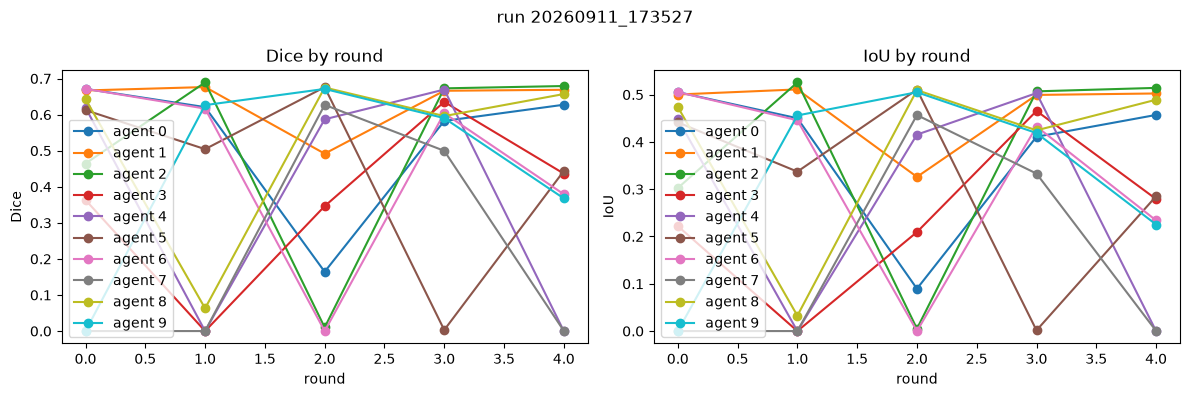

In [7]:
# Dice/IoU progression per agent across rounds (the swarm's optimization trace).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for agent_idx, group in ledger.sort_values("round").groupby("agent_idx"):
    axes[0].plot(group["round"], group["dice"], marker="o", label=f"agent {agent_idx}")
    axes[1].plot(group["round"], group["iou"], marker="o", label=f"agent {agent_idx}")
for ax, title in zip(axes, ["Dice", "IoU"]):
    ax.set_xlabel("round"); ax.set_ylabel(title); ax.set_title(f"{title} by round"); ax.legend()
fig.suptitle(f"run {RUN_ID}")
fig.tight_layout()
plt.show()

## 3. Load the agent's pipeline and (re)train

Only `pipeline.py` is persisted per agent/round -- the trained model itself is not. This mirrors `driver.py`: load the module, validate the contract, then run `preprocess -> build_model -> train` on the train split.

In [11]:
from typing import Any

In [13]:
from typing import Any

def load_pipeline_module(run_id: str, round_idx: int, agent_idx: int):
    path = settings.runs_dir / run_id / f"round_{round_idx}" / f"agent_{agent_idx}" / "pipeline.py"
    assert path.exists(), f"no pipeline.py at {path}"
    spec = importlib.util.spec_from_file_location(f"pipeline_{run_id}_{round_idx}_{agent_idx}", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    validate_module(mod)
    return mod


pipeline = load_pipeline_module(RUN_ID, ROUND, AGENT_IDX)
print(f"loaded pipeline.py for run={RUN_ID} round={ROUND} agent={AGENT_IDX}")
print(f"ledger says: dice={round_rows.loc[round_rows.agent_idx == AGENT_IDX, 'dice'].values}")

loaded pipeline.py for run=20260911_173527 round=1 agent=2
ledger says: dice=[0.6892179]


In [14]:
t0 = time.time()
X_train_processed = pipeline.preprocess(X_train)
model = pipeline.build_model(None)
model = pipeline.train(model, X_train_processed, y_train)
print(f"trained in {time.time() - t0:.1f}s")

trained in 290.0s


## 4. Inference on sample tiles

In [19]:
N_SAMPLES = 6
SAMPLE_SEED = 42

rng = np.random.default_rng(SAMPLE_SEED)
sample_idx = rng.choice(len(X_val), size=min(N_SAMPLES, len(X_val)), replace=False)
X_group, y_group = X_val[sample_idx], y_val[sample_idx]
group_ids = [val_ids[i] for i in sample_idx]

preds_group = infer(pipeline, model, X_group)
print(f"ran inference on {len(sample_idx)} val tiles: {group_ids}")

ran inference on 6 val tiles: [469, 522, 308, 642, 312, 58]


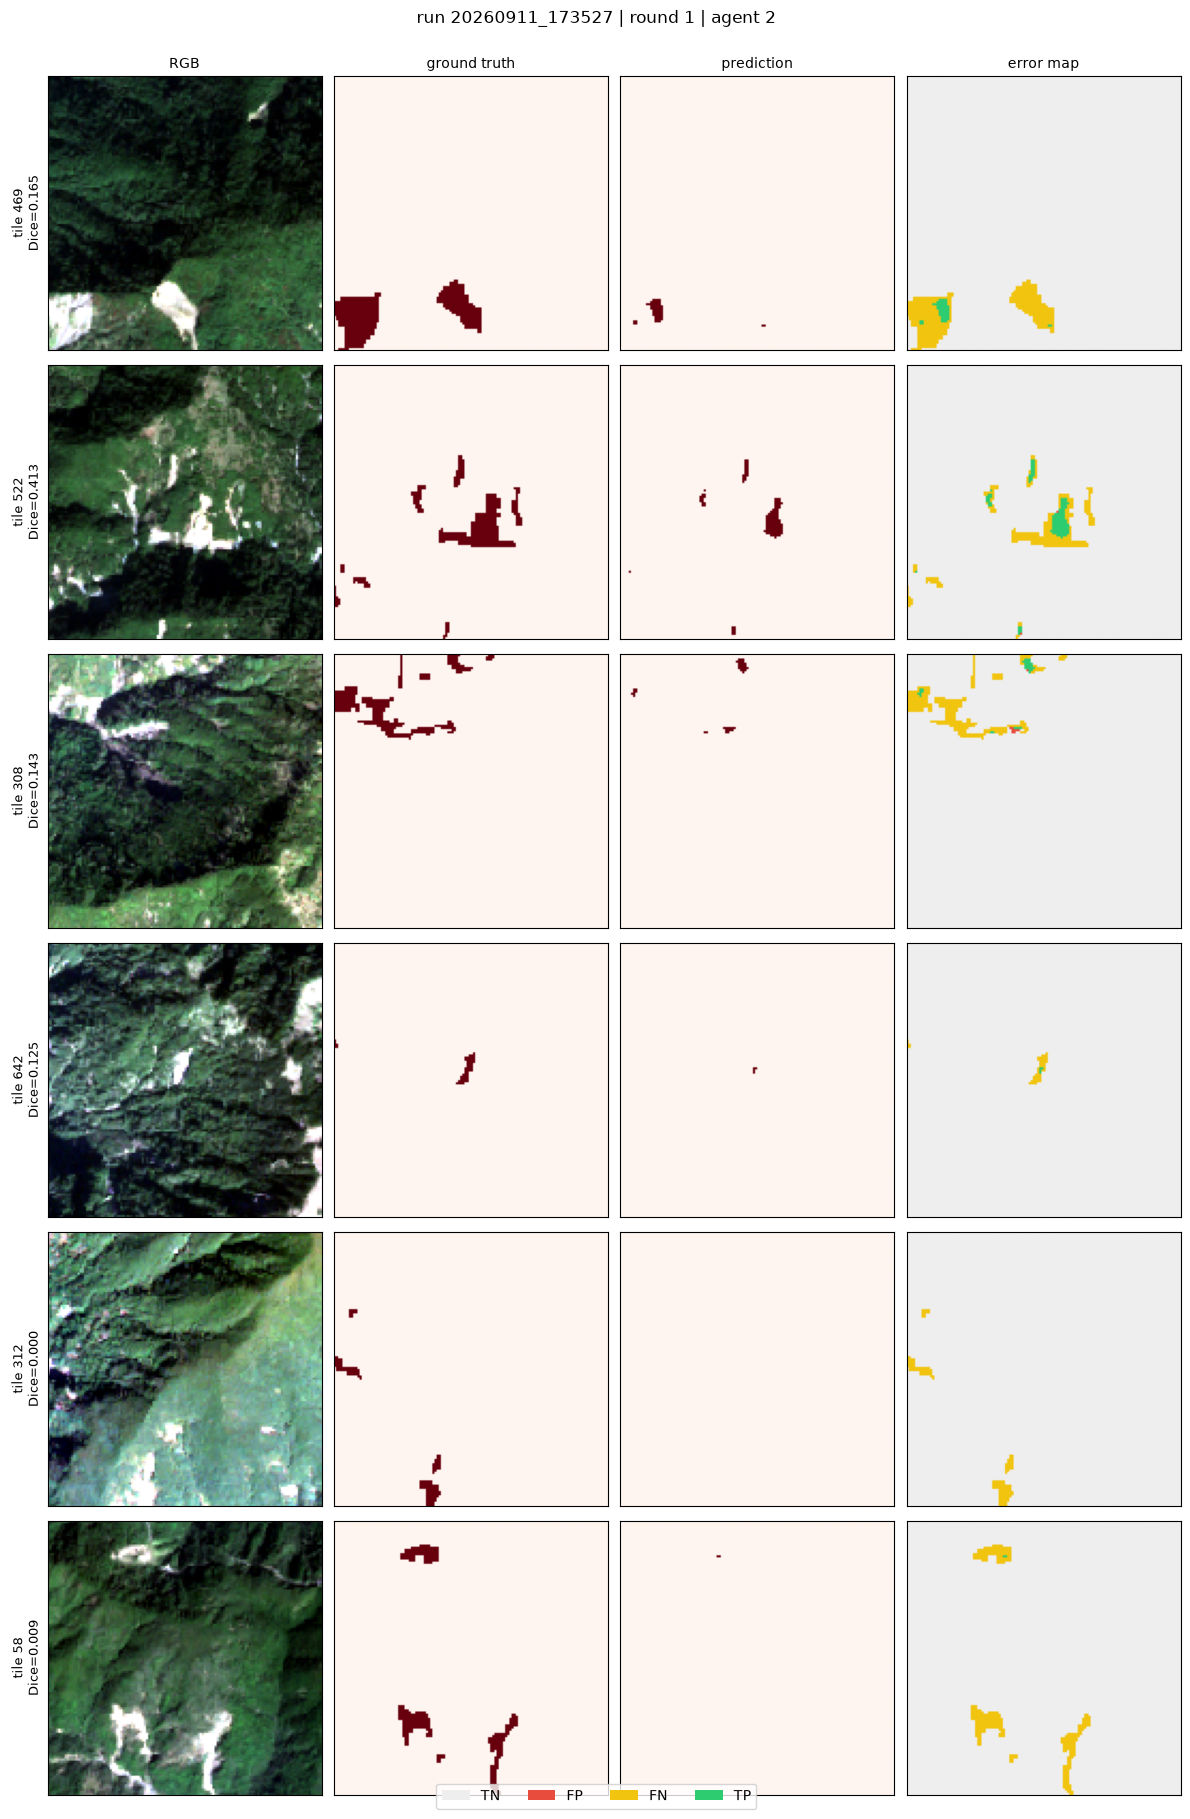

In [20]:
ERROR_CMAP = ListedColormap(["#eeeeee", "#e74c3c", "#f1c40f", "#2ecc71"])  # TN, FP, FN, TP
ERROR_LEGEND = [
    Patch(facecolor="#eeeeee", label="TN"),
    Patch(facecolor="#e74c3c", label="FP"),
    Patch(facecolor="#f1c40f", label="FN"),
    Patch(facecolor="#2ecc71", label="TP"),
]


def error_map(pred: np.ndarray, gt: np.ndarray) -> np.ndarray:
    pred, gt = pred.astype(bool), gt.astype(bool)
    out = np.zeros(pred.shape, dtype=np.uint8)
    out[~pred & gt] = 2   # FN
    out[pred & ~gt] = 1   # FP
    out[pred & gt] = 3    # TP
    return out


def plot_inference_grid(X, y_true, y_pred, ids) -> None:
    n = len(X)
    fig, axes = plt.subplots(n, 4, figsize=(12, 3 * n))
    axes = np.atleast_2d(axes)
    col_titles = ["RGB", "ground truth", "prediction", "error map"]
    for row in range(n):
        tile_dice = dice(y_pred[row], y_true[row])
        panels = [rgb_composite(X[row]), y_true[row], y_pred[row], error_map(y_pred[row], y_true[row])]
        for col, panel in enumerate(panels):
            ax = axes[row, col]
            if col == 3:
                ax.imshow(panel, cmap=ERROR_CMAP, vmin=0, vmax=3)
            elif col in (1, 2):
                ax.imshow(panel, cmap="Reds", vmin=0, vmax=1)
            else:
                ax.imshow(panel)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(col_titles[col], fontsize=10)
            if col == 0:
                ax.set_ylabel(f"tile {ids[row]}\nDice={tile_dice:.3f}", fontsize=9)
    fig.legend(handles=ERROR_LEGEND, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02 / n))
    fig.suptitle(f"run {RUN_ID} | round {ROUND} | agent {AGENT_IDX}", y=1.0)
    fig.tight_layout()
    plt.show()


plot_inference_grid(X_group, y_group, preds_group, group_ids)

## 5. Evaluation

Dice/IoU for the sampled group above, the full val split (matching what `eval/infer.py::evaluate` reports during a run), and per-tile score distribution + an aggregate spatial error map across the group.

In [21]:
group_scores = {"dice": dice(preds_group, y_group), "iou": iou(preds_group, y_group)}
print(f"sampled group ({len(sample_idx)} tiles): {group_scores}")

t0 = time.time()
val_scores = evaluate(pipeline, model, X_val, y_val)
print(f"full val split ({len(X_val)} tiles): {val_scores}  (evaluated in {time.time() - t0:.1f}s)")

sampled group (6 tiles): {'dice': 0.19025522044894608, 'iou': 0.10512820516644751}
full val split (100 tiles): {'dice': 0.39306708160530046, 'iou': 0.24460702566169132}  (evaluated in 6.2s)


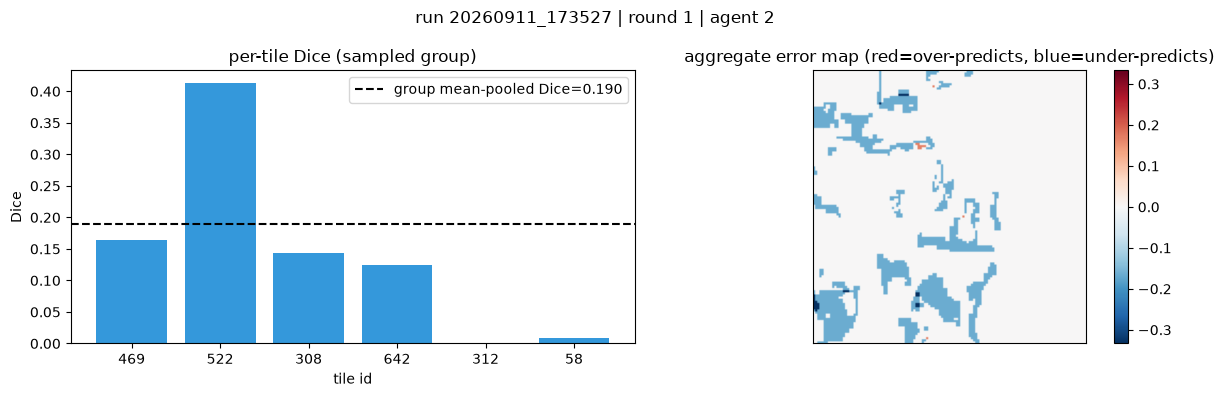

In [22]:
per_tile_dice = np.array([dice(preds_group[i], y_group[i]) for i in range(len(sample_idx))])


def aggregate_error_map(preds: np.ndarray, gt: np.ndarray) -> np.ndarray:
    """Per-pixel (FP frequency - FN frequency) across a group of tiles: >0 over-predicts here, <0 under-predicts."""
    fp_freq = (preds.astype(bool) & ~gt.astype(bool)).mean(axis=0)
    fn_freq = (~preds.astype(bool) & gt.astype(bool)).mean(axis=0)
    return fp_freq - fn_freq


def plot_aggregate_error_map(preds: np.ndarray, gt: np.ndarray, ax, title: str):
    net_error = aggregate_error_map(preds, gt)
    vabs = float(np.abs(net_error).max()) or 1.0
    im = ax.imshow(net_error, cmap="RdBu_r", vmin=-vabs, vmax=vabs)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(i) for i in group_ids], per_tile_dice, color="#3498db")
axes[0].axhline(group_scores["dice"], color="black", linestyle="--", label=f"group mean-pooled Dice={group_scores['dice']:.3f}")
axes[0].set_xlabel("tile id"); axes[0].set_ylabel("Dice"); axes[0].set_title("per-tile Dice (sampled group)")
axes[0].legend()

im = plot_aggregate_error_map(preds_group, y_group, axes[1], "aggregate error map (red=over-predicts, blue=under-predicts)")
fig.colorbar(im, ax=axes[1], fraction=0.046)

fig.suptitle(f"run {RUN_ID} | round {ROUND} | agent {AGENT_IDX}")
fig.tight_layout()
plt.show()

## 6. Compare agents within the selected round

Cheap comparison straight from the ledger (no retraining).

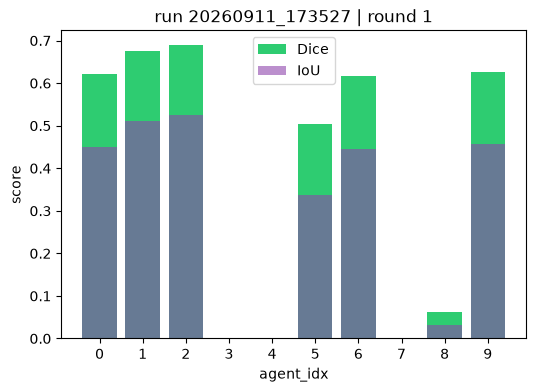

,agent_idx,dice,iou,success,debug_iters,carried_forward
10,0,6.207603e-01,4.500742e-01,True,2,False
11,1,6.764066e-01,5.110381e-01,True,0,False
12,2,6.892179e-01,5.258066e-01,True,0,False
13,3,1.227958e-12,1.227958e-12,True,0,False
14,4,1.227958e-12,1.227958e-12,True,1,False
15,5,5.042866e-01,3.371546e-01,True,0,False
16,6,6.166967e-01,4.458145e-01,True,2,False
17,7,1.227958e-12,1.227958e-12,True,0,False
18,8,6.299025e-02,3.251933e-02,True,0,False
19,9,6.263373e-01,4.559615e-01,True,0,False


In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_rows = round_rows.sort_values("agent_idx")
ax.bar(plot_rows["agent_idx"].astype(str), plot_rows["dice"], color="#2ecc71", label="Dice")
ax.bar(plot_rows["agent_idx"].astype(str), plot_rows["iou"], color="#8e44ad", alpha=0.6, label="IoU")
ax.set_xlabel("agent_idx"); ax.set_ylabel("score"); ax.set_title(f"run {RUN_ID} | round {ROUND}")
ax.legend()
plt.show()

plot_rows[["agent_idx", "dice", "iou", "success", "debug_iters", "carried_forward"]]

## 7. Final check — held-out test split

The test split has not been touched anywhere above: it wasn't used for training (section 3), for picking the visualized sample group (section 4), or for any evaluation number so far (sections 5-6). It's loaded and scored here exactly once, as a final unbiased check of the agent's pipeline + model from section 3.

In [ ]:
MAX_TEST_TILES = settings.max_val_tiles  # same cap as val above for a quick pass; set to None to score the full held-out set

X_test, y_test, test_ids = load_split("test", settings.dataset_dir, MAX_TEST_TILES)
print(f"test: X={X_test.shape} y={y_test.shape}")
pos_frac = y_test.mean()
tiles_with_landslide = (y_test.reshape(len(y_test), -1).sum(axis=1) > 0).mean()
print(f"test: landslide pixels={pos_frac:.3%}, tiles containing landslide={tiles_with_landslide:.1%}")

test: X=(100, 128, 128, 14) y=(100, 128, 128)
test: landslide pixels=2.591%, tiles containing landslide=65.0%


In [ ]:
t0 = time.time()
preds_test = infer(pipeline, model, X_test)
test_scores = {"dice": dice(preds_test, y_test), "iou": iou(preds_test, y_test)}
print(f"inferred {len(X_test)} test tiles in {time.time() - t0:.1f}s")

comparison = pd.DataFrame(
    [group_scores, val_scores, test_scores],
    index=[f"sampled group (n={len(sample_idx)})", f"val split (n={len(X_val)})", f"TEST split (n={len(X_test)}, held-out)"],
)
comparison

inferred 100 test tiles in 3.2s


,dice,iou
sampled group (n=6),0.440919,0.282807
val split (n=100),0.603954,0.432618
"TEST split (n=100, held-out)",0.671570,0.505537


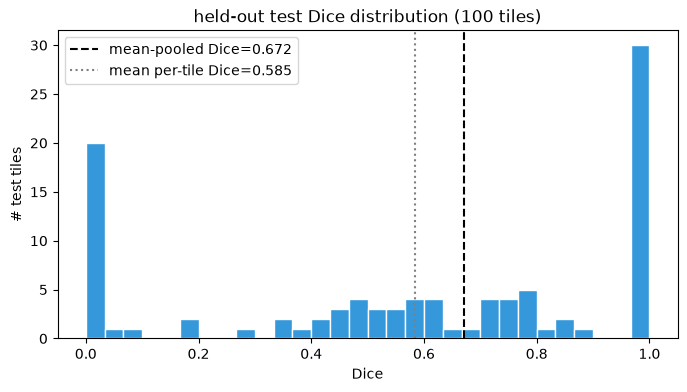

In [ ]:
per_tile_dice_test = np.array([dice(preds_test[i], y_test[i]) for i in range(len(X_test))])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_tile_dice_test, bins=30, color="#3498db", edgecolor="white")
ax.axvline(test_scores["dice"], color="black", linestyle="--", label=f"mean-pooled Dice={test_scores['dice']:.3f}")
ax.axvline(per_tile_dice_test.mean(), color="gray", linestyle=":", label=f"mean per-tile Dice={per_tile_dice_test.mean():.3f}")
ax.set_xlabel("Dice"); ax.set_ylabel("# test tiles")
ax.set_title(f"held-out test Dice distribution ({len(X_test)} tiles)")
ax.legend()
plt.show()

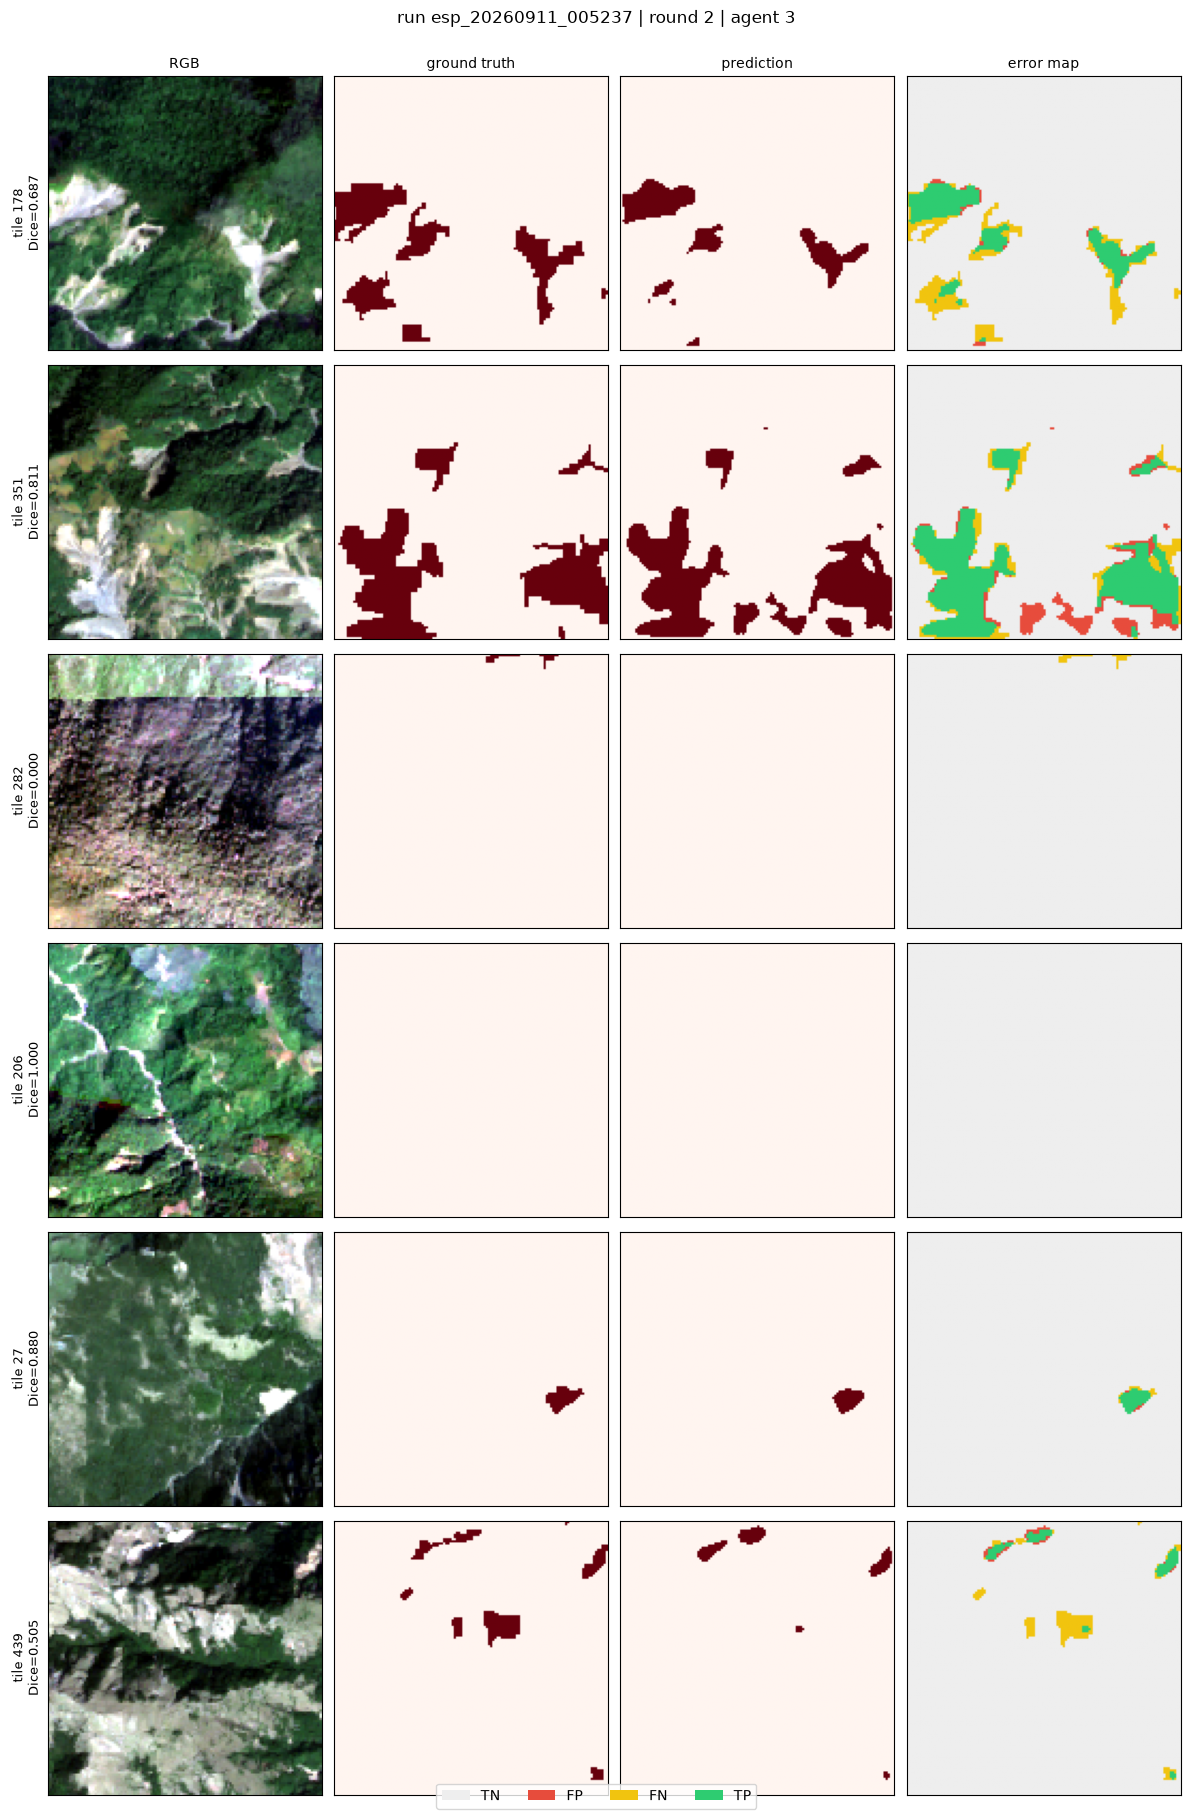

In [ ]:
# sample prediction maps on the held-out test set (same layout as section 4)
test_sample_idx = np.random.default_rng(SAMPLE_SEED).choice(len(X_test), size=min(N_SAMPLES, len(X_test)), replace=False)
plot_inference_grid(
    X_test[test_sample_idx], y_test[test_sample_idx], preds_test[test_sample_idx],
    [test_ids[i] for i in test_sample_idx],
)

# X - Extra Tests

In [3]:
from corpus.retrieve import format_for_prompt, retrieve_diverse
from config import Settings
from agents.prompts import RETRIEVAL_QUERY

settings = Settings()
agent_docs = retrieve_diverse(RETRIEVAL_QUERY, settings, settings.n_agents)

d:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
prompt = format_for_prompt(agent_docs[0], settings)

In [36]:
with open('file.txt', 'w', encoding='utf-8') as f:
    f.write(prompt)

# prompt